# Healthcare Analytics — Combined Project Notebook

**Author:** Nusrat — Data Analyst @ Wmolex pvt ltd

This notebook consolidates all models built across this project into one runnable file, organized into clearly separated sections. Each section is self-contained: it loads its own data, trains its own model(s), and reports its own evaluation — reusing common variable names (`df`, `X_train`, `models`, etc.) is safe across sections since each is independently sequenced.

## Table of Contents

0. [Heart Disease Classification — Baseline](#section-0) *(Logistic Regression / Random Forest / Gradient Boosting → Confusion Matrix, ROC-AUC, Feature Importance)*
1. [Model 1 — Patient Readmission Prediction](#section-1) *(Logistic Regression / Random Forest / XGBoost → Accuracy, Precision, Recall, F1, ROC-AUC)*
2. [Model 2 — Length of Stay Prediction](#section-2) *(Linear Regression / Random Forest Regressor → RMSE, MAE, R²)*
3. [Model 3 — Disease Prediction](#section-3) *(Random Forest / XGBoost → Accuracy, Precision, Recall, Confusion Matrix)*
4. [Model 4 — Hospital Resource Forecasting](#section-4) *(Prophet / ARIMA → Bed Occupancy, Patient Admissions, ICU Demand)*
5. [Consolidated Summary](#section-5)

**Datasets used:**
- `heart.csv` — 918 cardiac records (Section 0)
- `healthcare_admissions.csv` — 55,500 hospital admission records, 2019–2024 (Sections 1, 2, 4)
- `cleaned_healthcare_dataset.csv` — 500 patient records with diagnosis labels (Section 3)

**Known data-quality caveats carried over from individual notebooks** (kept transparent rather than smoothed over):
- Section 1's `Readmitted` label is a proxy (repeat patient name), not a verified clinical readmission flag.
- Section 2's R² is low (~0.09) — the admissions dataset's fields don't strongly predict stay duration.
- Section 3's accuracy is near chance level (~20% on 5 classes) — the diagnosis dataset shows little real signal in its features.
- Section 4's ICU Demand series is a proxy (Emergency-type admissions), since no ICU field exists in the source data.


<a id="section-0"></a>
---
# Section 0 — Heart Disease Classification (Baseline)

*Combines the original `machine_learning.ipynb` (feature engineering + training) and `model_evaluation.ipynb` (evaluation) into one flow.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


## 1. Load Data

In [2]:
df = pd.read_csv('heart.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['HeartDisease'].value_counts(normalize=True).round(3))


Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Target distribution:
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


## 2. Feature Engineering

We derive a few clinically-motivated features on top of the raw columns:

- **AgeGroup**: bucketed age ranges (risk tends to rise with age bands rather than linearly)
- **BP_Category**: resting blood pressure bucketed per standard clinical thresholds
- **Cholesterol_Category**: cholesterol bucketed per standard clinical thresholds
- **MaxHR_Reserve**: deviation of `MaxHR` from the age-predicted max heart rate (220 - Age), a common cardiology heuristic
- **Chol_Age_Ratio**: cholesterol relative to age, capturing risk accumulation


In [5]:
def bp_category(bp):
    if bp < 120:
        return 'Normal'
    elif bp < 130:
        return 'Elevated'
    elif bp < 140:
        return 'Stage1'
    else:
        return 'Stage2'

def chol_category(chol):
    if chol == 0:
        return 'Unknown'   # 0 cholesterol in this dataset denotes missing/unrecorded
    elif chol < 200:
        return 'Desirable'
    elif chol < 240:
        return 'Borderline'
    else:
        return 'High'

def age_group(age):
    if age < 40:
        return 'Under40'
    elif age < 50:
        return '40s'
    elif age < 60:
        return '50s'
    else:
        return '60plus'

df_fe = df.copy()
df_fe['BP_Category'] = df_fe['RestingBP'].apply(bp_category)
df_fe['Cholesterol_Category'] = df_fe['Cholesterol'].apply(chol_category)
df_fe['AgeGroup'] = df_fe['Age'].apply(age_group)
df_fe['MaxHR_Reserve'] = (220 - df_fe['Age']) - df_fe['MaxHR']
df_fe['Chol_Age_Ratio'] = df_fe['Cholesterol'] / df_fe['Age']

df_fe.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,BP_Category,Cholesterol_Category,AgeGroup,MaxHR_Reserve,Chol_Age_Ratio
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,Stage2,High,40s,8,7.225000
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,Stage2,Desirable,40s,15,3.673469
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,Stage1,High,Under40,85,7.648649
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,Stage1,Borderline,40s,64,4.458333
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,Stage2,Desirable,50s,44,3.611111


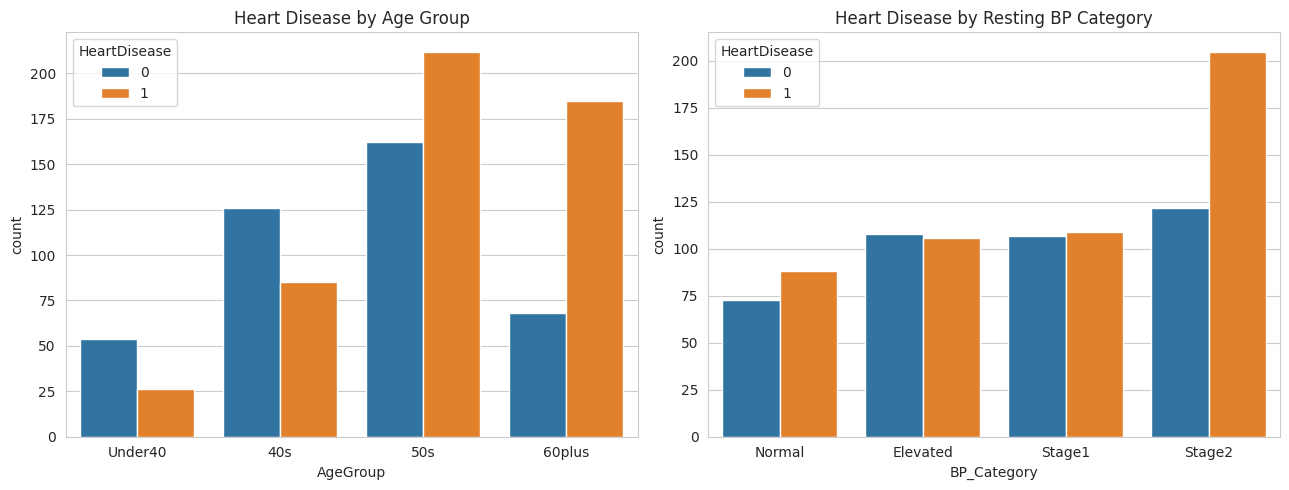

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df_fe, x='AgeGroup', hue='HeartDisease', order=['Under40','40s','50s','60plus'], ax=axes[0])
axes[0].set_title('Heart Disease by Age Group')
sns.countplot(data=df_fe, x='BP_Category', hue='HeartDisease', order=['Normal','Elevated','Stage1','Stage2'], ax=axes[1])
axes[1].set_title('Heart Disease by Resting BP Category')
plt.tight_layout()
plt.show()


## 3. Preprocessing Pipeline

In [7]:
target = 'HeartDisease'
X = df_fe.drop(columns=[target])
y = df_fe[target]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'BP_Category', 'Cholesterol_Category', 'AgeGroup']
Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'MaxHR_Reserve', 'Chol_Age_Ratio']


In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 4. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (734, 16), Test shape: (184, 16)


## 5. Train Multiple Models

We train three candidate models inside a preprocessing pipeline, then compare quick holdout accuracy/F1 to pick a primary model for the evaluation notebook. Random Forest is retained as the primary model since tree-based models expose feature importances directly and typically handle this feature mix well.


In [10]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results[name] = {'accuracy': acc, 'f1': f1}
    fitted_pipelines[name] = pipe
    print(f"{name:20s} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
results_df


LogisticRegression   | Accuracy: 0.8913 | F1: 0.9020


RandomForest         | Accuracy: 0.8750 | F1: 0.8900
GradientBoosting     | Accuracy: 0.8913 | F1: 0.9020


,accuracy,f1
LogisticRegression,0.891304,0.901961
GradientBoosting,0.891304,0.901961
RandomForest,0.875000,0.889952


In [11]:
best_model_name = results_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
print(f"Best model selected: {best_model_name}")


Best model selected: LogisticRegression


## 6. Save Artifacts

Save the fitted pipelines and the held-out test split so `model_evaluation.ipynb` can load them directly without re-running training.


In [12]:
joblib.dump(fitted_pipelines, 'fitted_pipelines.joblib')
joblib.dump(best_model_name, 'best_model_name.joblib')

X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)

print("Artifacts saved: fitted_pipelines.joblib, best_model_name.joblib, X_train.csv, X_test.csv, y_train.csv, y_test.csv")


Artifacts saved: fitted_pipelines.joblib, best_model_name.joblib, X_train.csv, X_test.csv, y_train.csv, y_test.csv


---
**Next:** open `model_evaluation.ipynb` for classification report, confusion matrix, ROC curve, and feature importance analysis on these trained models.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load Artifacts

In [14]:
fitted_pipelines = joblib.load('fitted_pipelines.joblib')
best_model_name = joblib.load('best_model_name.joblib')

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').iloc[:, 0]

print(f"Best model: {best_model_name}")
print(f"Test set shape: {X_test.shape}")
print(f"Models available: {list(fitted_pipelines.keys())}")


Best model: LogisticRegression
Test set shape: (184, 16)
Models available: ['LogisticRegression', 'RandomForest', 'GradientBoosting']


## 2. Classification Metrics — All Models

In [15]:
metrics_rows = []
for name, pipe in fitted_pipelines.items():
    preds = pipe.predict(X_test)
    metrics_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('F1', ascending=False)
metrics_df.round(4)


,Accuracy,Precision,Recall,F1
Model,,,,
LogisticRegression,0.8913,0.9020,0.9020,0.902
GradientBoosting,0.8913,0.9020,0.9020,0.902
RandomForest,0.8750,0.8692,0.9118,0.890


In [16]:
best_pipeline = fitted_pipelines[best_model_name]
best_preds = best_pipeline.predict(X_test)

print(f"Detailed classification report — {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=['No Disease', 'Disease']))


Detailed classification report — LogisticRegression

              precision    recall  f1-score   support

  No Disease       0.88      0.88      0.88        82
     Disease       0.90      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



## 3. Confusion Matrix

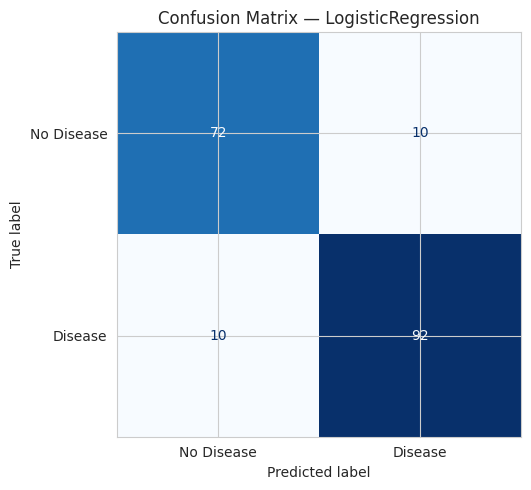

True Negatives:  72
False Positives: 10
False Negatives: 10
True Positives:  92


In [17]:
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")


## 4. ROC Curve — All Models

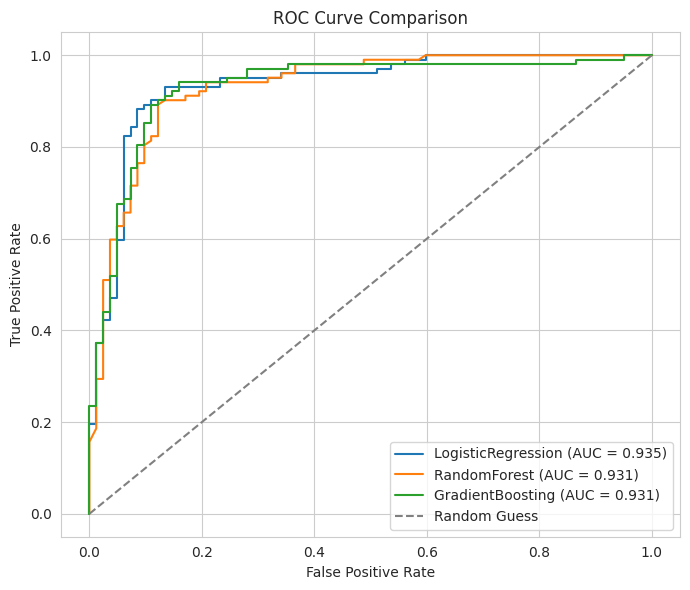

In [18]:
plt.figure(figsize=(7, 6))

for name, pipe in fitted_pipelines.items():
    probs = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 5. Feature Importance

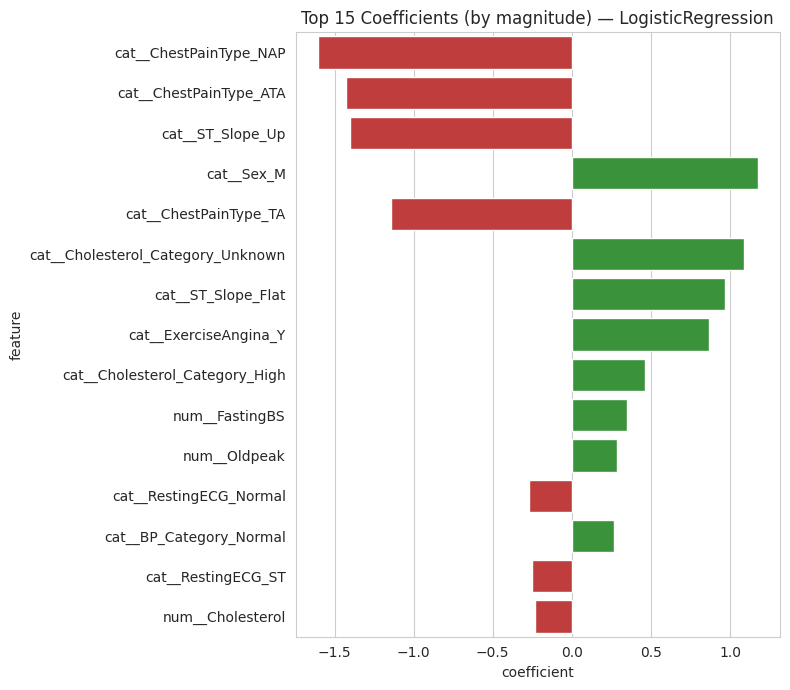

In [19]:
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocessor']
    return preprocessor.get_feature_names_out()

model_step = best_pipeline.named_steps['classifier']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    fi_df.reset_index(drop=True)
elif hasattr(model_step, 'coef_'):
    coefs = model_step.coef_[0]
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
    fi_df['abs_coef'] = fi_df['coefficient'].abs()
    fi_df = fi_df.sort_values('abs_coef', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    colors = ['#d62728' if c < 0 else '#2ca02c' for c in fi_df['coefficient']]
    sns.barplot(data=fi_df, x='coefficient', y='feature', palette=colors)
    plt.title(f'Top 15 Coefficients (by magnitude) — {best_model_name}')
    plt.tight_layout()
    plt.show()

    fi_df.reset_index(drop=True)
else:
    print("Selected model does not expose feature importances or coefficients directly.")


## 6. Summary

- Best model by F1 on the held-out test set is reported above, with full precision/recall/F1 breakdown.
- The confusion matrix shows the trade-off between false positives (unnecessary follow-up) and false negatives (missed diagnosis) — clinically, minimizing false negatives is usually the priority.
- ROC/AUC comparison across all three models gives a threshold-independent view of discriminative power.
- Feature importance highlights which clinical variables (including the engineered features from `machine_learning.ipynb`) drive predictions most.


<a id="section-1"></a>
---
# Section 1 — Patient Readmission Prediction

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load Data

In [21]:
df = pd.read_csv('healthcare_admissions.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [22]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [23]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


## 2. Engineer the Readmission Target

A patient is marked as **readmitted** if their `Name` appears more than once across the dataset's admission records.


In [24]:
name_counts = df['Name'].value_counts()
df['Readmitted'] = df['Name'].map(name_counts).apply(lambda c: 1 if c > 1 else 0)

print(df['Readmitted'].value_counts())
print(df['Readmitted'].value_counts(normalize=True).round(4))


Readmitted
0    44485
1    11015
Name: count, dtype: int64
Readmitted
0    0.8015
1    0.1985
Name: proportion, dtype: float64


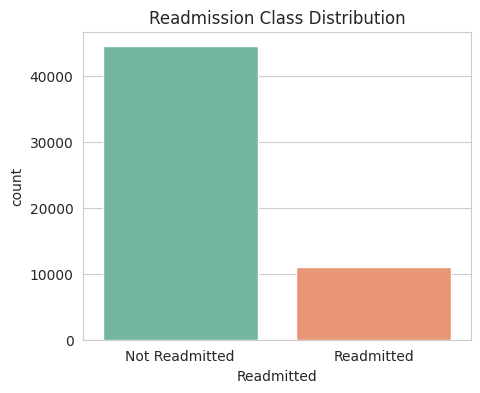

In [25]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Readmitted', palette='Set2')
plt.title('Readmission Class Distribution')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.show()


## 3. Feature Engineering

- `Date of Admission` / `Discharge Date` → parsed to datetime, used to derive `Length_of_Stay` (days)
- `Admission_Year`, `Admission_Month` extracted for potential seasonal signal
- Raw identifier columns (`Name`, `Doctor`, `Hospital`, `Room Number`) dropped — they are not generalizable predictive features and risk leaking the target (since `Name` was used to build it)


In [26]:
df_fe = df.copy()
df_fe['Date of Admission'] = pd.to_datetime(df_fe['Date of Admission'])
df_fe['Discharge Date'] = pd.to_datetime(df_fe['Discharge Date'])

df_fe['Length_of_Stay'] = (df_fe['Discharge Date'] - df_fe['Date of Admission']).dt.days
df_fe['Admission_Year'] = df_fe['Date of Admission'].dt.year
df_fe['Admission_Month'] = df_fe['Date of Admission'].dt.month

df_fe = df_fe.drop(columns=['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date'])
df_fe.head()


,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Readmitted,Length_of_Stay,Admission_Year,Admission_Month
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,0,2,2024,1
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,0,6,2019,8
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,0,15,2022,9
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,0,30,2020,11
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,1,20,2022,9


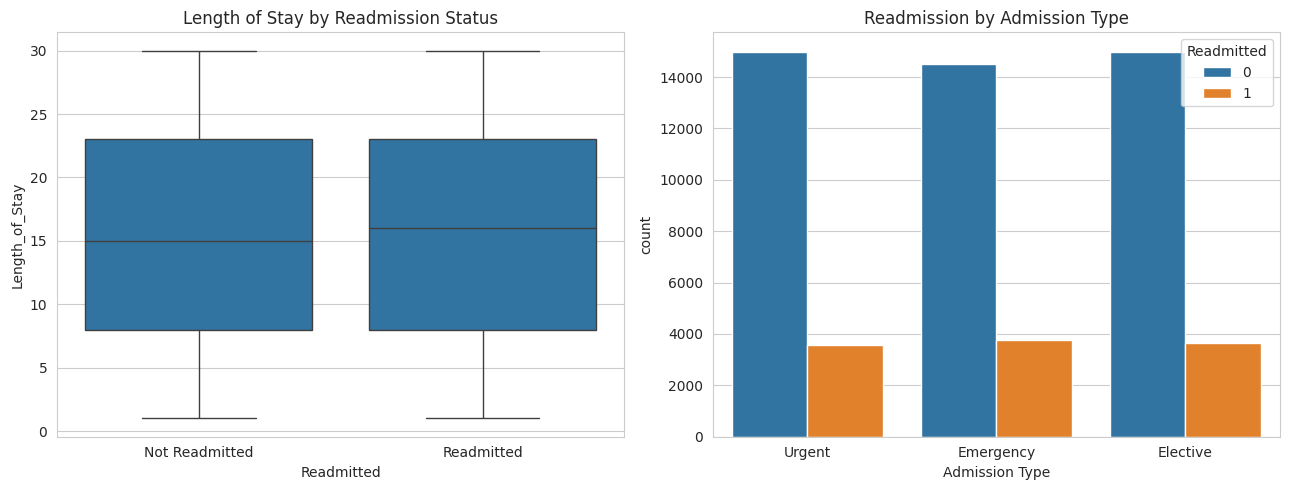

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_fe, x='Readmitted', y='Length_of_Stay', ax=axes[0])
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted'])
axes[0].set_title('Length of Stay by Readmission Status')

sns.countplot(data=df_fe, x='Admission Type', hue='Readmitted', ax=axes[1])
axes[1].set_title('Readmission by Admission Type')
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline

In [28]:
target = 'Readmitted'
X = df_fe.drop(columns=[target])
y = df_fe[target]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
Numeric columns: ['Age', 'Billing Amount', 'Length_of_Stay', 'Admission_Year', 'Admission_Month']


In [29]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 5. Train / Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train readmission rate: {y_train.mean():.4f} | Test readmission rate: {y_test.mean():.4f}")


Train shape: (44400, 12), Test shape: (11100, 12)
Train readmission rate: 0.1985 | Test readmission rate: 0.1985


## 6. Train Models

Logistic Regression, Random Forest, and XGBoost — each wrapped in the same preprocessing pipeline for a fair comparison. `scale_pos_weight` is set for XGBoost to account for the class imbalance (~80/20 split).


In [31]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss',
        random_state=RANDOM_STATE, use_label_encoder=False
    )
}

fitted_pipelines = {}
pred_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    pred_results[name] = {'preds': preds, 'probs': probs}
    print(f"{name} trained.")


LogisticRegression trained.


RandomForest trained.


XGBoost trained.


## 7. Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC

In [32]:
metrics_rows = []
for name, r in pred_results.items():
    metrics_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, r['preds']),
        'Precision': precision_score(y_test, r['preds']),
        'Recall': recall_score(y_test, r['preds']),
        'F1': f1_score(y_test, r['preds']),
        'ROC-AUC': roc_auc_score(y_test, r['probs'])
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('ROC-AUC', ascending=False)
metrics_df.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
RandomForest,0.9580,0.9983,0.7898,0.8819,0.9040
XGBoost,0.6156,0.2606,0.5098,0.3448,0.6150
LogisticRegression,0.5094,0.2002,0.4916,0.2846,0.5013


In [33]:
best_model_name = metrics_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
best_preds = pred_results[best_model_name]['preds']
best_probs = pred_results[best_model_name]['probs']

print(f"Best model by ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=['Not Readmitted', 'Readmitted']))


Best model by ROC-AUC: RandomForest

                precision    recall  f1-score   support

Not Readmitted       0.95      1.00      0.97      8897
    Readmitted       1.00      0.79      0.88      2203

      accuracy                           0.96     11100
     macro avg       0.97      0.89      0.93     11100
  weighted avg       0.96      0.96      0.96     11100



### Confusion Matrix — Best Model

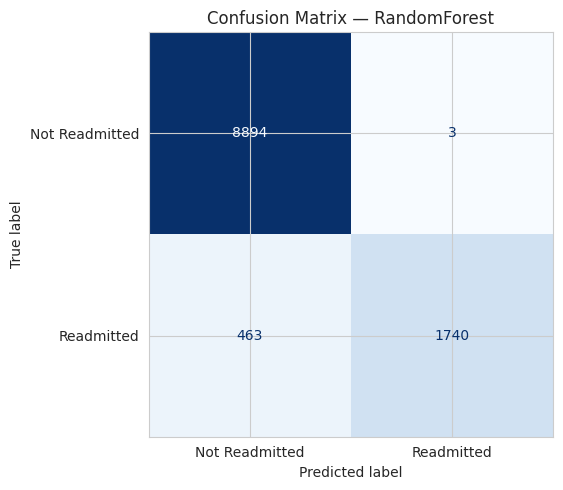

In [34]:
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()


### ROC Curve — All Models Compared

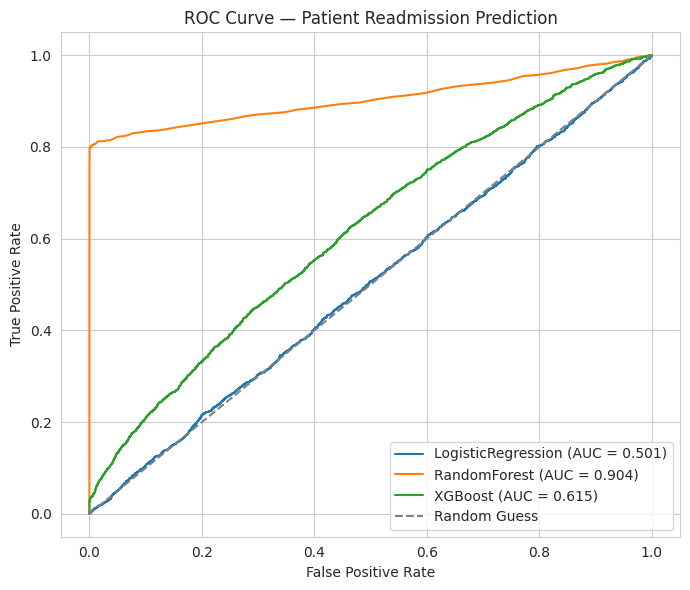

In [35]:
plt.figure(figsize=(7, 6))
for name, r in pred_results.items():
    fpr, tpr, _ = roc_curve(y_test, r['probs'])
    auc = roc_auc_score(y_test, r['probs'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Patient Readmission Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Model Comparison — Bar Chart

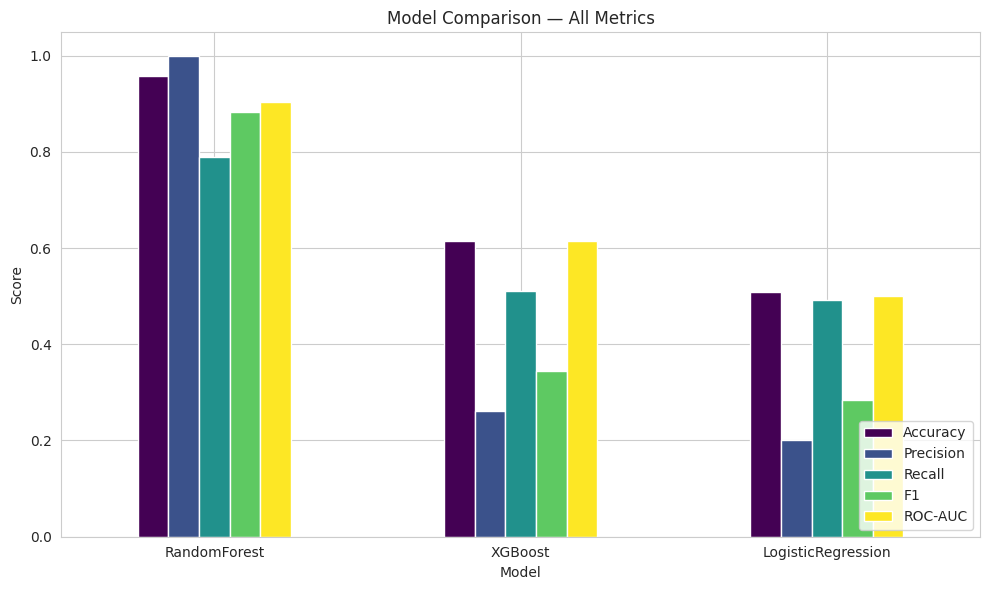

In [36]:
metrics_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 6), colormap='viridis'
)
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Feature Importance (Best Tree-Based Model)

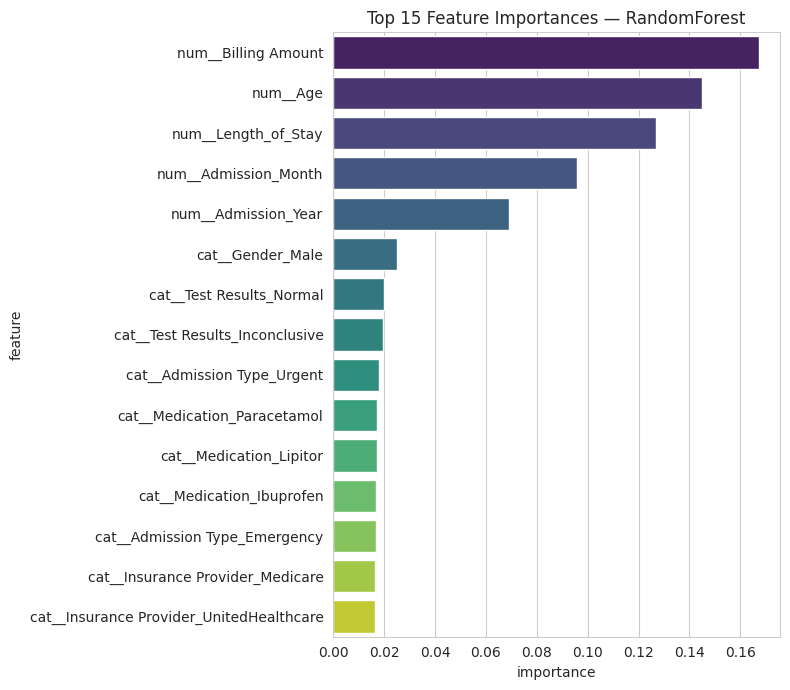

In [37]:
def get_feature_names(pipeline):
    return pipeline.named_steps['preprocessor'].get_feature_names_out()

model_step = best_pipeline.named_steps['classifier']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(model_step, 'coef_'):
    coefs = model_step.coef_[0]
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
    fi_df['abs_coef'] = fi_df['coefficient'].abs()
    fi_df = fi_df.sort_values('abs_coef', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=fi_df, x='coefficient', y='feature', palette='coolwarm')
    plt.title(f'Top 15 Coefficients — {best_model_name}')
    plt.tight_layout()
    plt.show()


## 9. Summary

- **Target caveat:** `Readmitted` is a proxy (repeat patient name across records), not a clinically verified readmission flag — swap in a real label if/when available for production use.
- Three models (Logistic Regression, Random Forest, XGBoost) were trained on identical preprocessing and evaluated on the same held-out 20% test split.
- Best model selected by **ROC-AUC**, with full Accuracy / Precision / Recall / F1 breakdown and confusion matrix above.
- `Length_of_Stay`, `Admission Type`, and `Medical Condition` are among the engineered/raw features driving predictions — check the feature importance chart for the exact ranking on this run.
- **Next steps:** if a true readmission label (e.g., "readmitted within 30 days" with patient IDs and multiple visit records) becomes available, re-run Section 2 with that column directly — the rest of the pipeline requires no changes.


<a id="section-2"></a>
---
# Section 2 — Length of Stay Prediction

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load Data

In [39]:
df = pd.read_csv('healthcare_admissions.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [40]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB

Missing v

## 2. Compute the Target — Length of Stay

In [41]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

print(df['Length_of_Stay'].describe())


count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length_of_Stay, dtype: float64


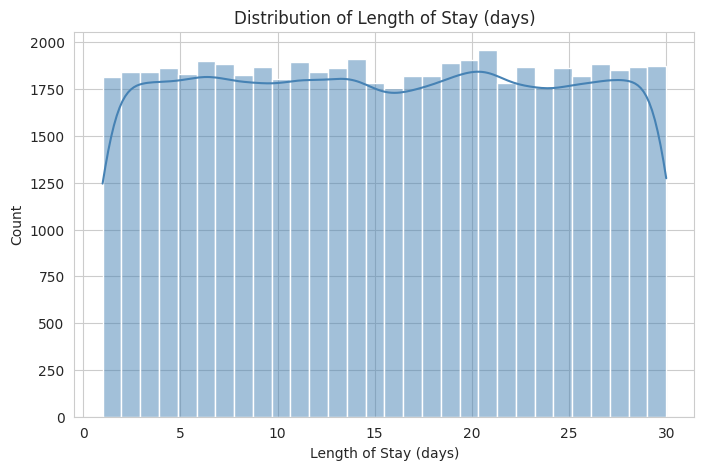

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Length_of_Stay'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Length of Stay (days)')
plt.xlabel('Length of Stay (days)')
plt.show()


## 3. Feature Engineering

- `Admission_Year`, `Admission_Month`, `Admission_DayOfWeek` extracted from `Date of Admission` for seasonal/weekday signal
- Raw identifiers (`Name`, `Doctor`, `Hospital`, `Room Number`) dropped — not generalizable predictors
- Raw date columns dropped after deriving features and the target (to avoid leaking `Discharge Date`, which was used to compute `Length_of_Stay` directly)


In [43]:
df_fe = df.copy()
df_fe['Admission_Year'] = df_fe['Date of Admission'].dt.year
df_fe['Admission_Month'] = df_fe['Date of Admission'].dt.month
df_fe['Admission_DayOfWeek'] = df_fe['Date of Admission'].dt.dayofweek

df_fe = df_fe.drop(columns=['Name', 'Doctor', 'Hospital', 'Room Number',
                             'Date of Admission', 'Discharge Date'])
df_fe.head()


,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_DayOfWeek
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,2,2024,1,2
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,6,2019,8,1
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,15,2022,9,3
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,30,2020,11,2
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,20,2022,9,0


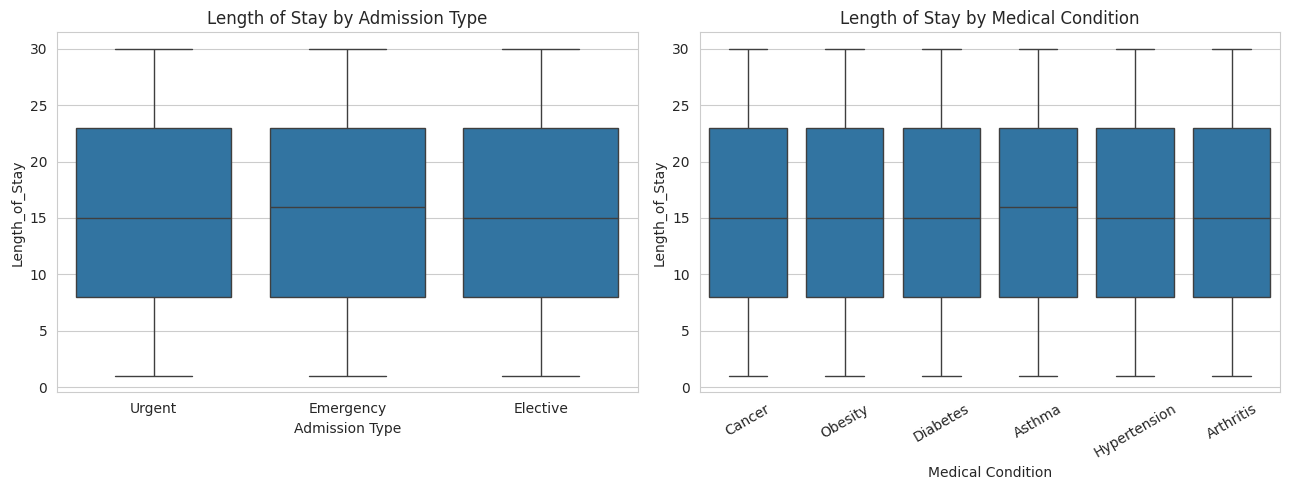

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_fe, x='Admission Type', y='Length_of_Stay', ax=axes[0])
axes[0].set_title('Length of Stay by Admission Type')

sns.boxplot(data=df_fe, x='Medical Condition', y='Length_of_Stay', ax=axes[1])
axes[1].set_title('Length of Stay by Medical Condition')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline

In [45]:
target = 'Length_of_Stay'
X = df_fe.drop(columns=[target])
y = df_fe[target]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
Numeric columns: ['Age', 'Billing Amount', 'Admission_Year', 'Admission_Month', 'Admission_DayOfWeek']


In [46]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 5. Train / Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (44400, 12), Test shape: (11100, 12)


## 6. Train Models — Linear Regression & Random Forest Regressor

In [48]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
}

fitted_pipelines = {}
pred_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    pred_results[name] = preds
    print(f"{name} trained.")


LinearRegression trained.


RandomForestRegressor trained.


## 7. Evaluation — RMSE, MAE, R² Score

In [49]:
metrics_rows = []
for name, preds in pred_results.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metrics_rows.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('RMSE')
metrics_df.round(4)


,RMSE,MAE,R2 Score
Model,,,
RandomForestRegressor,8.2138,6.9657,0.0938
LinearRegression,8.6320,7.4821,-0.0008


In [50]:
best_model_name = metrics_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
best_preds = pred_results[best_model_name]

print(f"Best model by RMSE: {best_model_name}")
print(f"RMSE: {metrics_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"MAE:  {metrics_df.loc[best_model_name, 'MAE']:.4f}")
print(f"R2:   {metrics_df.loc[best_model_name, 'R2 Score']:.4f}")


Best model by RMSE: RandomForestRegressor
RMSE: 8.2138
MAE:  6.9657
R2:   0.0938


### Model Comparison — Bar Chart

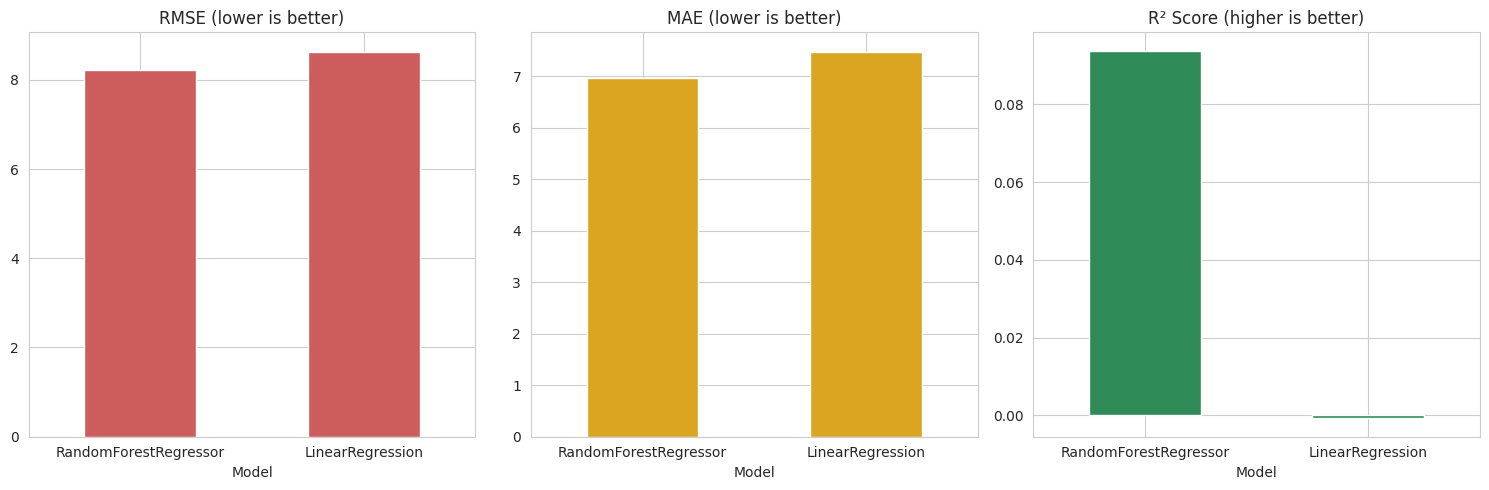

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_df['RMSE'].plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('RMSE (lower is better)')
axes[0].tick_params(axis='x', rotation=0)

metrics_df['MAE'].plot(kind='bar', ax=axes[1], color='goldenrod')
axes[1].set_title('MAE (lower is better)')
axes[1].tick_params(axis='x', rotation=0)

metrics_df['R2 Score'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('R² Score (higher is better)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Predicted vs. Actual — Best Model

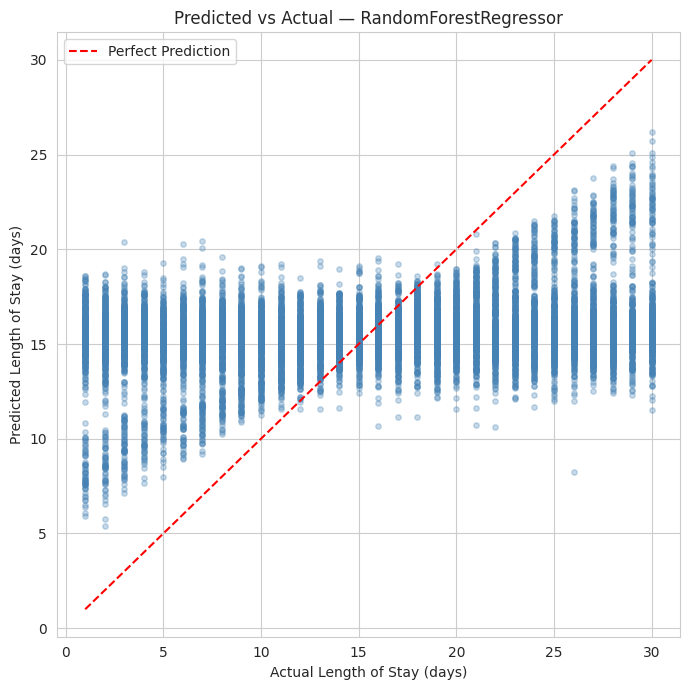

In [52]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3, s=15, color='steelblue')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Length of Stay (days)')
plt.ylabel('Predicted Length of Stay (days)')
plt.title(f'Predicted vs Actual — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()


### Residuals Plot — Best Model

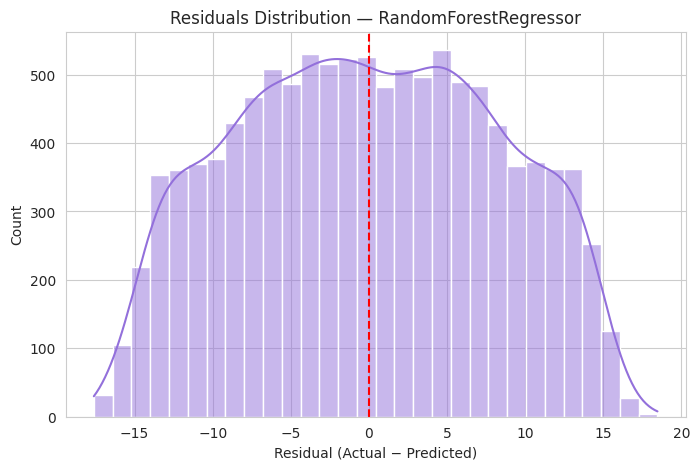

In [53]:
residuals = y_test - best_preds

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='mediumpurple')
plt.axvline(0, color='red', linestyle='--')
plt.title(f'Residuals Distribution — {best_model_name}')
plt.xlabel('Residual (Actual − Predicted)')
plt.show()


## 8. Feature Importance (Random Forest)

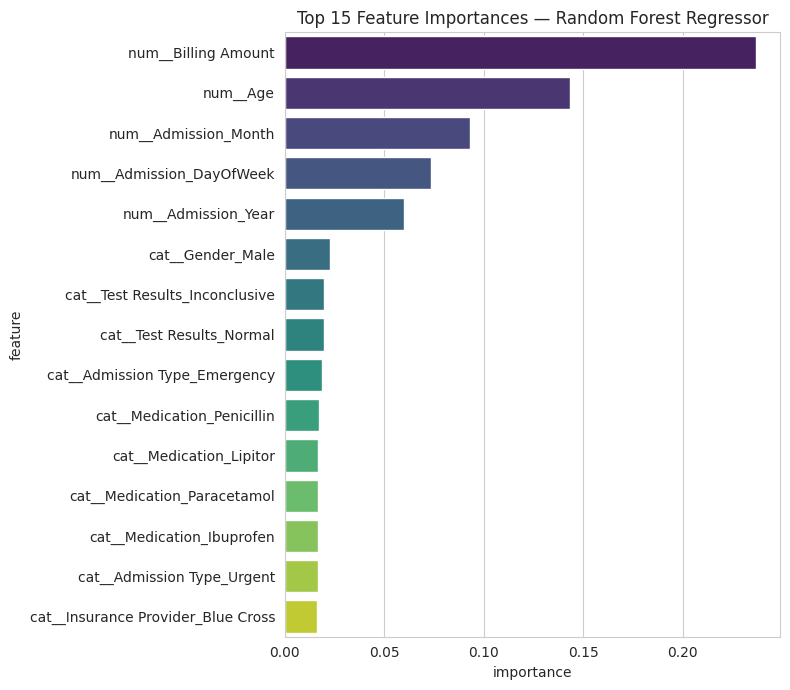

In [54]:
def get_feature_names(pipeline):
    return pipeline.named_steps['preprocessor'].get_feature_names_out()

rf_pipeline = fitted_pipelines['RandomForestRegressor']
importances = rf_pipeline.named_steps['regressor'].feature_importances_
feat_names = get_feature_names(rf_pipeline)

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest Regressor')
plt.tight_layout()
plt.show()


## 9. Summary

- `Length_of_Stay` is a directly computed target (discharge date − admission date), not a proxy — more reliable ground truth than Model 1's readmission label.
- Linear Regression and Random Forest Regressor were compared on identical preprocessing and the same 20% held-out split.
- Best model selected by **RMSE**, with MAE and R² reported alongside for a fuller picture of fit quality.
- Predicted-vs-actual and residuals plots above show how well (or how loosely) length of stay can be predicted from the available admission-level features — R² here reflects how much variance these features actually explain, which is worth calling out honestly if it's low (synthetic/randomized fields like `Medical Condition` and `Admission Type` may carry limited real signal for stay duration in this dataset).


<a id="section-3"></a>
---
# Section 3 — Disease Prediction

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load Data

In [56]:
df = pd.read_csv('cleaned_healthcare_dataset.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (500, 15)


,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date,Is_Outlier,Age_Group,BMI_Category,Cholesterol_Category,BP_Category
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01,False,Middle Age (51-65),Obese,High,Normal
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02,False,Senior (66+),Obese,Desirable,Elevated
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03,False,Teen (13-19),Overweight,Desirable,High
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04,False,Senior (66+),Normal,Desirable,Elevated
4,5,60,Male,130,96,206,39.3,Diabetes,Medication,2024-01-05,False,Middle Age (51-65),Obese,Borderline High,Elevated


In [57]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            500 non-null    int64  
 1   Age                   500 non-null    int64  
 2   Gender                500 non-null    str    
 3   Blood_Pressure        500 non-null    int64  
 4   Heart_Rate            500 non-null    int64  
 5   Cholesterol_Level     500 non-null    int64  
 6   BMI                   500 non-null    float64
 7   Diagnosis             500 non-null    str    
 8   Treatment_Plan        500 non-null    str    
 9   Follow_Up_Date        500 non-null    str    
 10  Is_Outlier            500 non-null    bool   
 11  Age_Group             500 non-null    str    
 12  BMI_Category          500 non-null    str    
 13  Cholesterol_Category  500 non-null    str    
 14  BP_Category           500 non-null    str    
dtypes: bool(1), float64(1), int64(5), 

## 2. Target Distribution

Diagnosis
Healthy                    104
Hypertension               101
Coronary Artery Disease    101
Hyperlipidemia             101
Diabetes                    93
Name: count, dtype: int64


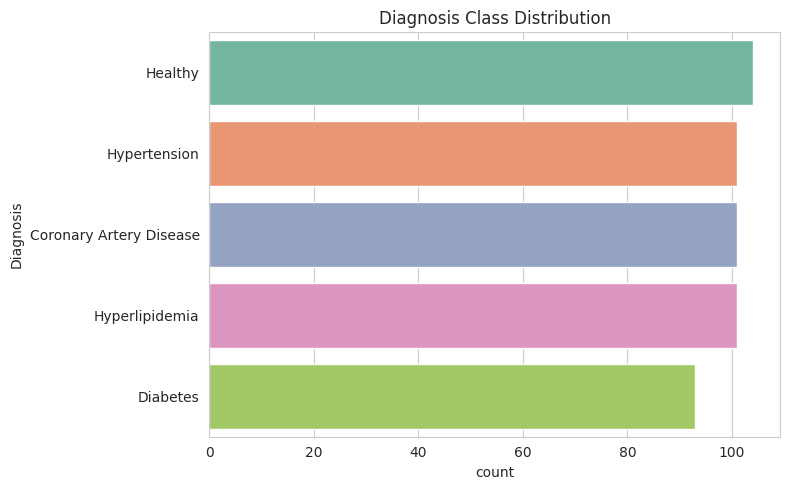

In [58]:
print(df['Diagnosis'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='Diagnosis', order=df['Diagnosis'].value_counts().index, palette='Set2')
plt.title('Diagnosis Class Distribution')
plt.tight_layout()
plt.show()


## 3. Feature Preparation

Dropping `Patient_ID`, `Treatment_Plan` (target leakage — assigned post-diagnosis), and `Follow_Up_Date` (non-informative identifier).


In [59]:
df_fe = df.drop(columns=['Patient_ID', 'Treatment_Plan', 'Follow_Up_Date'])
df_fe.head()


,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Is_Outlier,Age_Group,BMI_Category,Cholesterol_Category,BP_Category
0,51,Female,97,90,282,35.2,Hypertension,False,Middle Age (51-65),Obese,High,Normal
1,92,Other,129,80,169,32.3,Healthy,False,Senior (66+),Obese,Desirable,Elevated
2,14,Male,172,76,157,29.9,Diabetes,False,Teen (13-19),Overweight,Desirable,High
3,71,Female,131,82,150,19.4,Coronary Artery Disease,False,Senior (66+),Normal,Desirable,Elevated
4,60,Male,130,96,206,39.3,Diabetes,False,Middle Age (51-65),Obese,Borderline High,Elevated


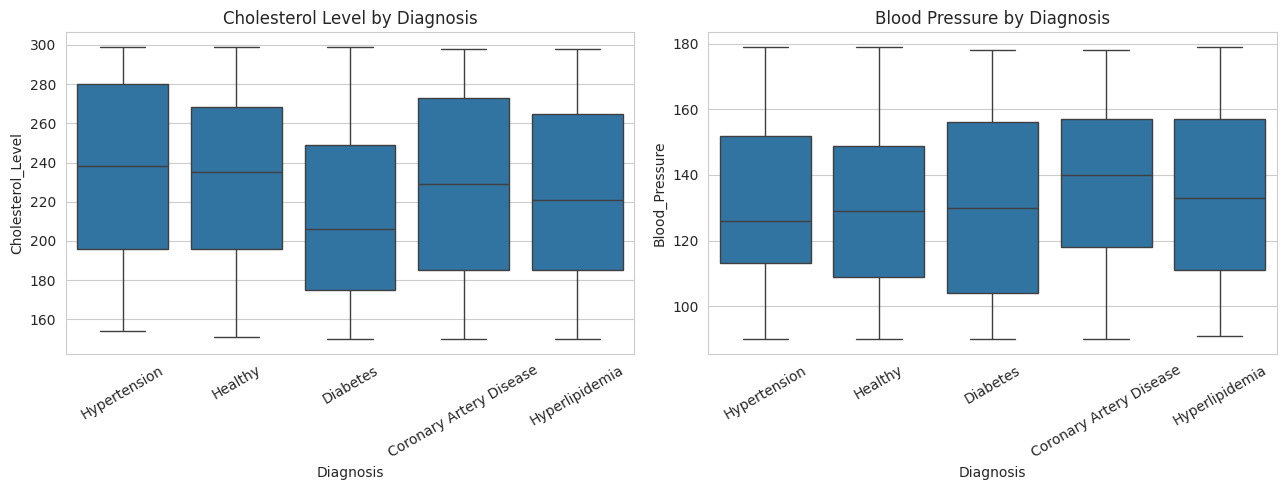

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_fe, x='Diagnosis', y='Cholesterol_Level', ax=axes[0])
axes[0].set_title('Cholesterol Level by Diagnosis')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_fe, x='Diagnosis', y='Blood_Pressure', ax=axes[1])
axes[1].set_title('Blood Pressure by Diagnosis')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline

In [61]:
target = 'Diagnosis'
X = df_fe.drop(columns=[target])
y_raw = df_fe[target]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
print("Classes:", list(label_encoder.classes_))

categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Classes: ['Coronary Artery Disease', 'Diabetes', 'Healthy', 'Hyperlipidemia', 'Hypertension']
Categorical columns: ['Gender', 'Is_Outlier', 'Age_Group', 'BMI_Category', 'Cholesterol_Category', 'BP_Category']
Numeric columns: ['Age', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'BMI']


In [62]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 5. Train / Test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (400, 11), Test shape: (100, 11)


## 6. Train Models — Random Forest & XGBoost

In [64]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        eval_metric='mlogloss', random_state=RANDOM_STATE, use_label_encoder=False
    )
}

fitted_pipelines = {}
pred_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    pred_results[name] = preds
    print(f"{name} trained.")


RandomForest trained.


XGBoost trained.


## 7. Evaluation — Accuracy, Precision, Recall

In [65]:
metrics_rows = []
for name, preds in pred_results.items():
    metrics_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (macro)': precision_score(y_test, preds, average='macro'),
        'Recall (macro)': recall_score(y_test, preds, average='macro')
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('Accuracy', ascending=False)
metrics_df.round(4)


,Accuracy,Precision (macro),Recall (macro)
Model,,,
RandomForest,0.22,0.2119,0.2178
XGBoost,0.19,0.1919,0.1897


In [66]:
best_model_name = metrics_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
best_preds = pred_results[best_model_name]

print(f"Best model by Accuracy: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=label_encoder.classes_))


Best model by Accuracy: RandomForest

                         precision    recall  f1-score   support

Coronary Artery Disease       0.21      0.20      0.21        20
               Diabetes       0.14      0.16      0.15        19
                Healthy       0.31      0.38      0.34        21
         Hyperlipidemia       0.17      0.10      0.12        20
           Hypertension       0.24      0.25      0.24        20

               accuracy                           0.22       100
              macro avg       0.21      0.22      0.21       100
           weighted avg       0.21      0.22      0.21       100



### Model Comparison — Bar Chart

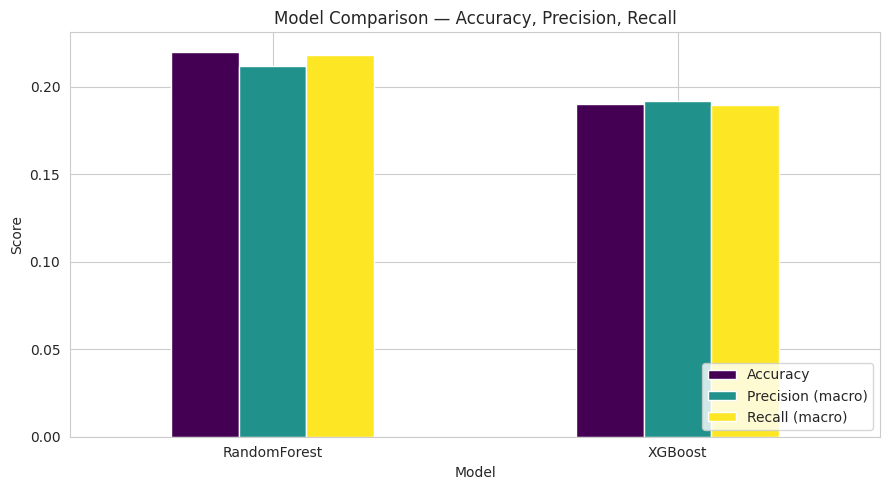

In [67]:
metrics_df.plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Model Comparison — Accuracy, Precision, Recall')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Confusion Matrix — Both Models

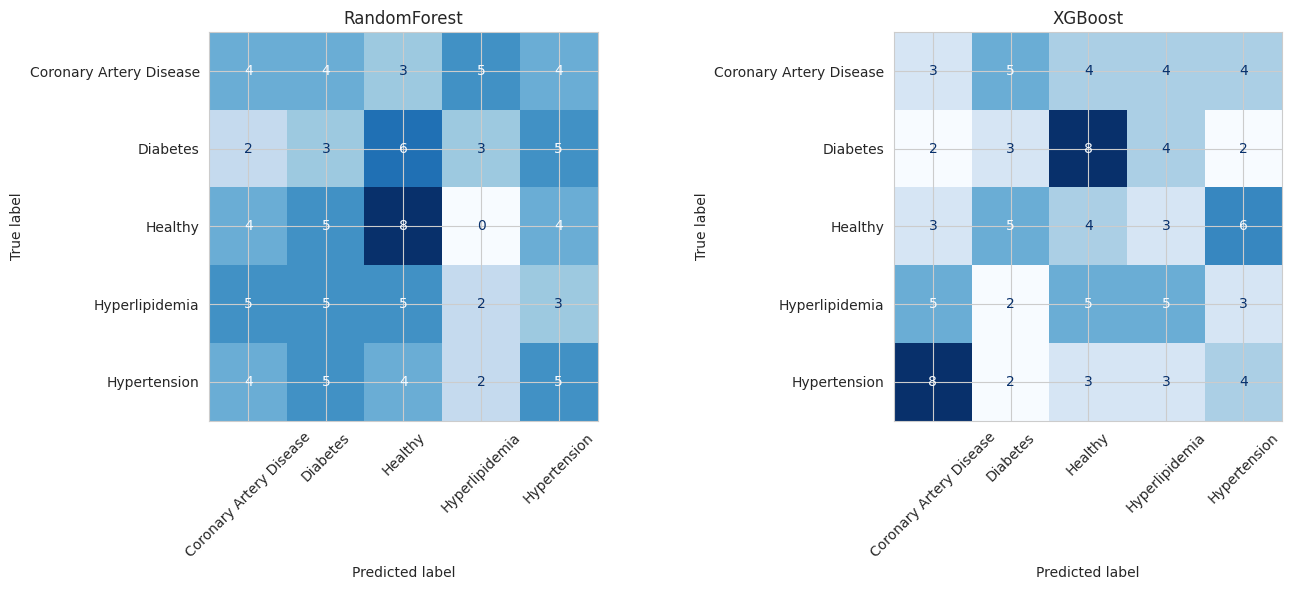

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, preds) in zip(axes, pred_results.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 9. Feature Importance (Best Model)

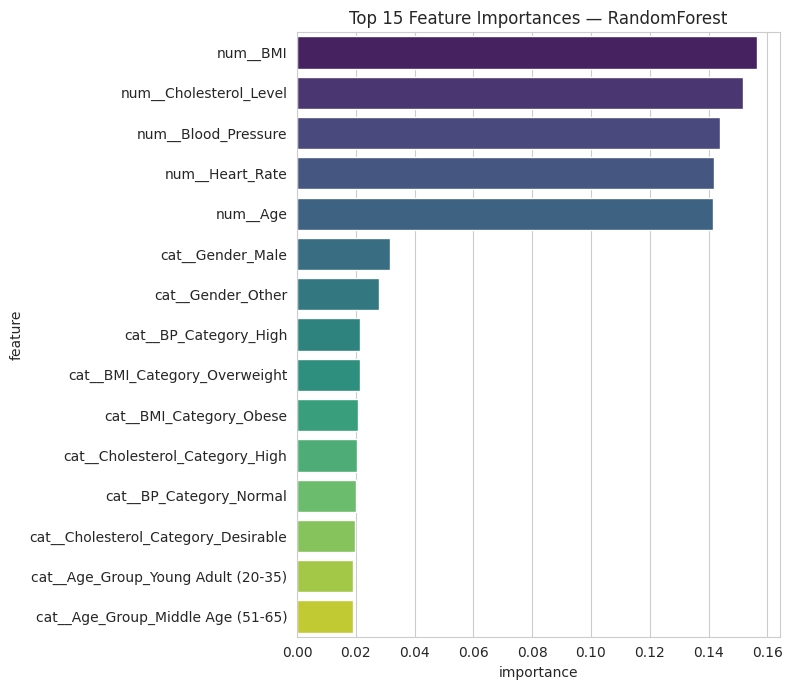

In [69]:
def get_feature_names(pipeline):
    return pipeline.named_steps['preprocessor'].get_feature_names_out()

model_step = best_pipeline.named_steps['classifier']
importances = model_step.feature_importances_
feat_names = get_feature_names(best_pipeline)

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title(f'Top 15 Feature Importances — {best_model_name}')
plt.tight_layout()
plt.show()


## 10. Summary

- 5-class disease prediction on a reasonably balanced dataset (93–104 records per class out of 500 total) — a small sample, so treat metrics as directional rather than production-grade.
- `Treatment_Plan` was deliberately excluded as a leakage risk since it's assigned based on diagnosis, not before it.
- Random Forest and XGBoost compared on identical preprocessing and the same held-out 20% split, with per-class precision/recall and confusion matrices for both models above.
- With only 500 records for 5 classes (~100 per class, ~80 in training per class), results here should be read as a proof-of-concept baseline — more data would materially firm up these estimates.


<a id="section-4"></a>
---
# Section 4 — Hospital Resource Forecasting

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

HORIZON = 90  # days to forecast forward, also the size of the holdout window for evaluation


Importing plotly failed. Interactive plots will not work.


## 1. Load Data

In [71]:
df = pd.read_csv('healthcare_admissions.csv')
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date of Admission'].min().date()} to {df['Date of Admission'].max().date()}")
df.head()


Shape: (55500, 15)
Date range: 2019-05-08 to 2024-05-07


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 2. Build the Three Daily Time Series

- **Admissions**: `groupby` day, count of rows
- **Bed Occupancy**: for each admission, +1 on admission day and −1 the day after discharge; cumulative sum gives beds occupied on any given day
- **ICU Demand (proxy)**: daily count of `Admission Type == 'Emergency'` records


In [72]:
full_range = pd.date_range(df['Date of Admission'].min(), df['Date of Admission'].max(), freq='D')

# --- Patient Admissions ---
admissions_daily = df.groupby(df['Date of Admission'].dt.date).size()
admissions_daily.index = pd.to_datetime(admissions_daily.index)
admissions_daily = admissions_daily.reindex(full_range, fill_value=0)

# --- Bed Occupancy ---
occ = pd.Series(0, index=full_range)
admit_counts = df['Date of Admission'].dt.normalize().value_counts()
discharge_next_day = (df['Discharge Date'] + pd.Timedelta(days=1)).dt.normalize().value_counts()
occ = occ.add(admit_counts, fill_value=0).sub(discharge_next_day, fill_value=0)
occ = occ.reindex(full_range, fill_value=0).cumsum()

# --- ICU Demand (proxy: Emergency admissions per day) ---
icu_daily = df[df['Admission Type'] == 'Emergency'].groupby(
    df.loc[df['Admission Type'] == 'Emergency', 'Date of Admission'].dt.date
).size()
icu_daily.index = pd.to_datetime(icu_daily.index)
icu_daily = icu_daily.reindex(full_range, fill_value=0)

series = {
    'Patient Admissions': admissions_daily,
    'Bed Occupancy': occ,
    'ICU Demand (proxy)': icu_daily
}

for name, s in series.items():
    print(f"{name}: mean={s.mean():.1f}, std={s.std():.1f}, min={s.min()}, max={s.max()}")


Patient Admissions: mean=30.4, std=6.1, min=12, max=50
Bed Occupancy: mean=498.4, std=40.7, min=27.0, max=593.0
ICU Demand (proxy): mean=10.0, std=3.5, min=1, max=24


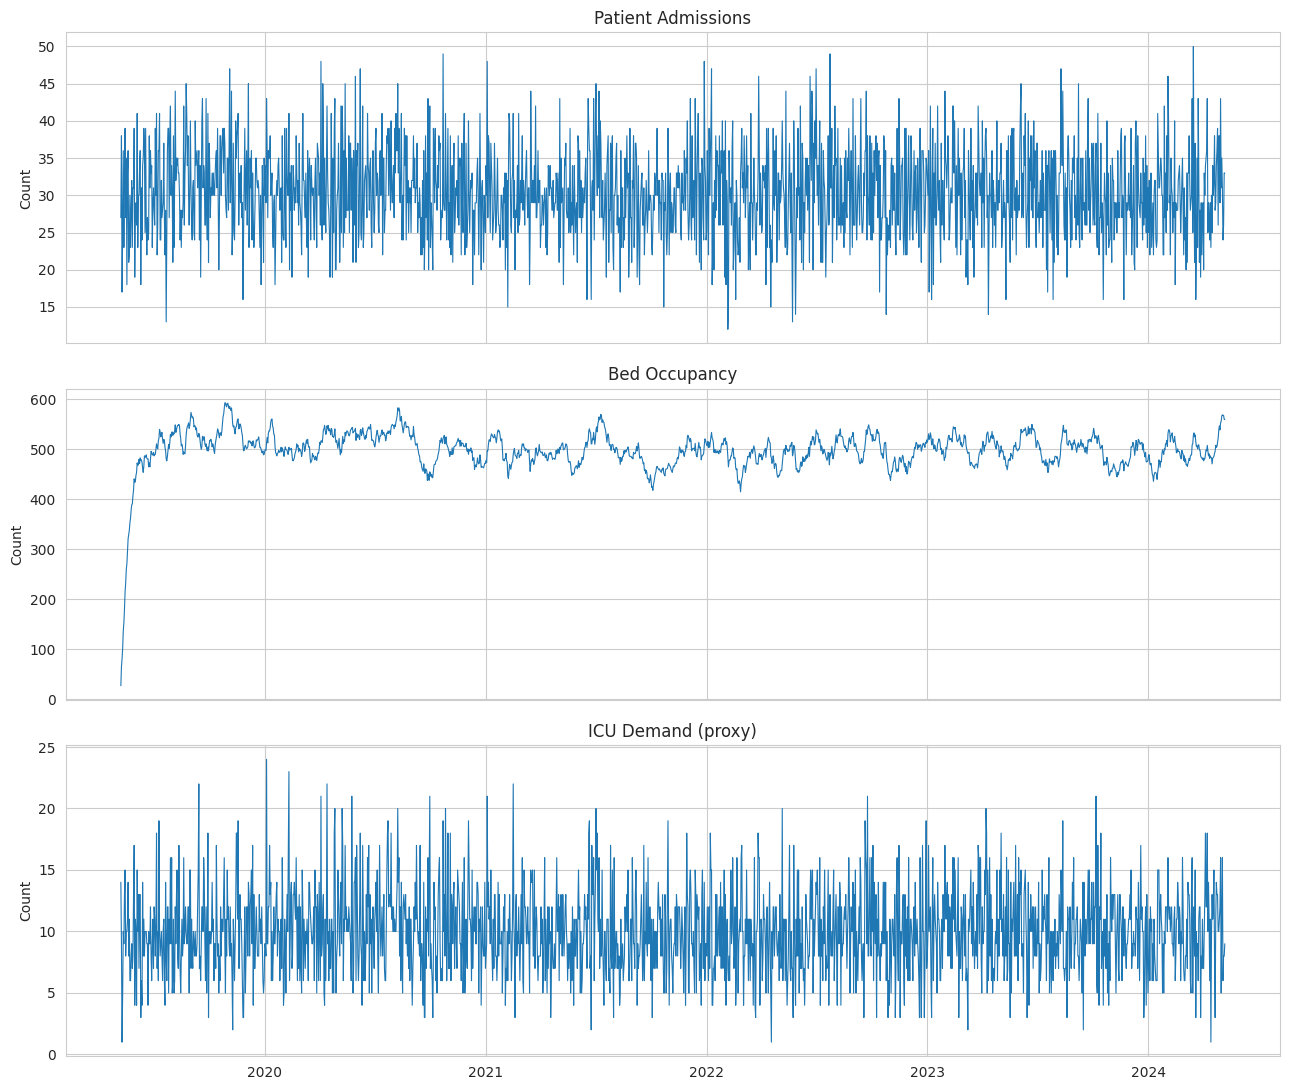

In [73]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (name, s) in zip(axes, series.items()):
    ax.plot(s.index, s.values, linewidth=0.8)
    ax.set_title(name)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 3. Train / Holdout Split

Last 90 days held out from each series to evaluate forecast accuracy before projecting forward.


In [74]:
def train_test_split_series(s, horizon=HORIZON):
    return s.iloc[:-horizon], s.iloc[-horizon:]

splits = {name: train_test_split_series(s) for name, s in series.items()}
for name, (train, test) in splits.items():
    print(f"{name}: train={len(train)} days, test={len(test)} days")


Patient Admissions: train=1737 days, test=90 days
Bed Occupancy: train=1737 days, test=90 days
ICU Demand (proxy): train=1737 days, test=90 days


## 4. Prophet Models

One Prophet model per series, with weekly + yearly seasonality (daily seasonality off — these are already daily aggregates).


In [75]:
def fit_prophet(train_series):
    df_p = train_series.reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                interval_width=0.9)
    m.fit(df_p)
    return m

prophet_models = {}
prophet_forecasts = {}

for name, (train, test) in splits.items():
    m = fit_prophet(train)
    future = m.make_future_dataframe(periods=HORIZON)
    fc = m.predict(future)
    prophet_models[name] = m
    prophet_forecasts[name] = fc
    print(f"Prophet fit complete: {name}")


10:57:33 - cmdstanpy - INFO - Chain [1] start processing


10:57:34 - cmdstanpy - INFO - Chain [1] done processing


10:57:34 - cmdstanpy - INFO - Chain [1] start processing


Prophet fit complete: Patient Admissions


10:57:34 - cmdstanpy - INFO - Chain [1] done processing


10:57:34 - cmdstanpy - INFO - Chain [1] start processing


10:57:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet fit complete: Bed Occupancy


Prophet fit complete: ICU Demand (proxy)


## 5. ARIMA Models

One ARIMA(2,1,2) model per series — a reasonable general-purpose order for daily count data with mild trend/noise; weekly seasonality isn't modeled directly by plain ARIMA (SARIMA would be needed for that), so Prophet is expected to have an edge on the more seasonal series.


In [76]:
arima_models = {}
arima_forecasts = {}

for name, (train, test) in splits.items():
    model = ARIMA(train.values, order=(2, 1, 2))
    fitted = model.fit()
    fc = fitted.get_forecast(steps=HORIZON)
    arima_models[name] = fitted
    arima_forecasts[name] = fc
    print(f"ARIMA fit complete: {name}")


ARIMA fit complete: Patient Admissions


ARIMA fit complete: Bed Occupancy


ARIMA fit complete: ICU Demand (proxy)


## 6. Forecast Accuracy on Holdout (MAE, RMSE)


In [77]:
eval_rows = []

for name, (train, test) in splits.items():
    # Prophet: pull predictions for the holdout window
    fc_p = prophet_forecasts[name]
    prophet_holdout_pred = fc_p.set_index('ds').loc[test.index, 'yhat'].values
    prophet_mae = mean_absolute_error(test.values, prophet_holdout_pred)
    prophet_rmse = np.sqrt(mean_squared_error(test.values, prophet_holdout_pred))

    # ARIMA
    arima_holdout_pred = arima_forecasts[name].predicted_mean
    arima_mae = mean_absolute_error(test.values, arima_holdout_pred)
    arima_rmse = np.sqrt(mean_squared_error(test.values, arima_holdout_pred))

    eval_rows.append({'Series': name, 'Model': 'Prophet', 'MAE': prophet_mae, 'RMSE': prophet_rmse})
    eval_rows.append({'Series': name, 'Model': 'ARIMA', 'MAE': arima_mae, 'RMSE': arima_rmse})

eval_df = pd.DataFrame(eval_rows).set_index(['Series', 'Model'])
eval_df.round(2)


MAE   RMSE
Series             Model                
Patient Admissions Prophet   4.84   6.29
                   ARIMA     4.76   6.17
Bed Occupancy      Prophet  30.83  42.80
                   ARIMA    25.14  28.67
ICU Demand (proxy) Prophet   2.85   3.49
                   ARIMA     2.76   3.42

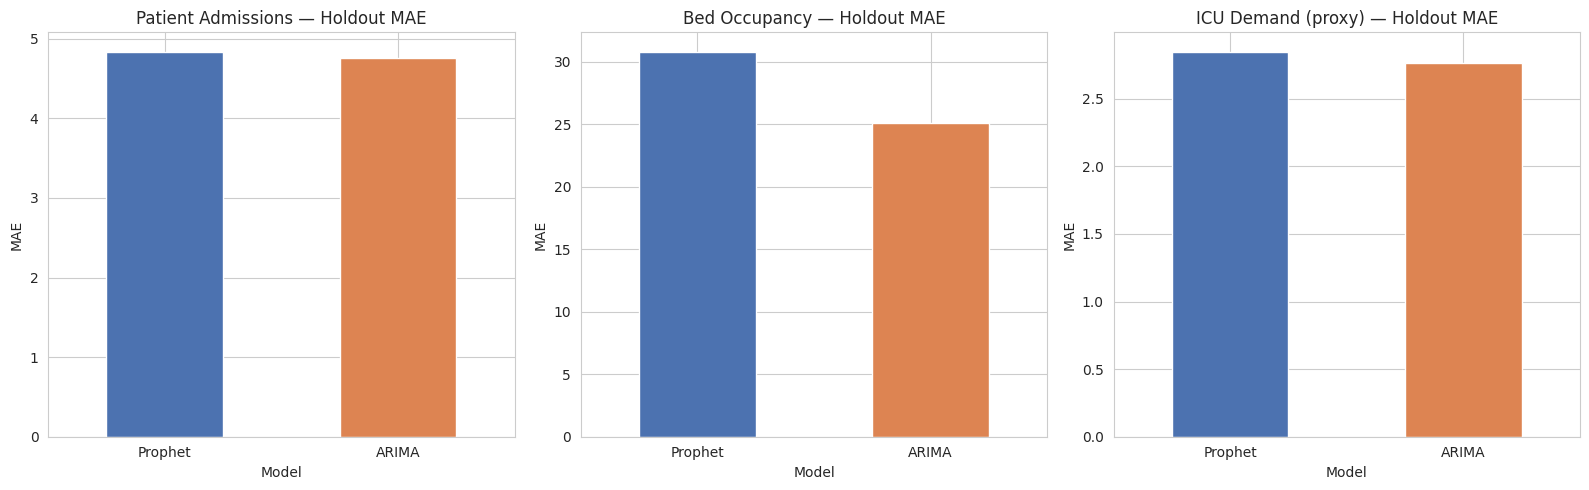

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, series.keys()):
    sub = eval_df.loc[name]
    sub['MAE'].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'{name} — Holdout MAE')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 7. Holdout Forecast vs Actual — Visual Check


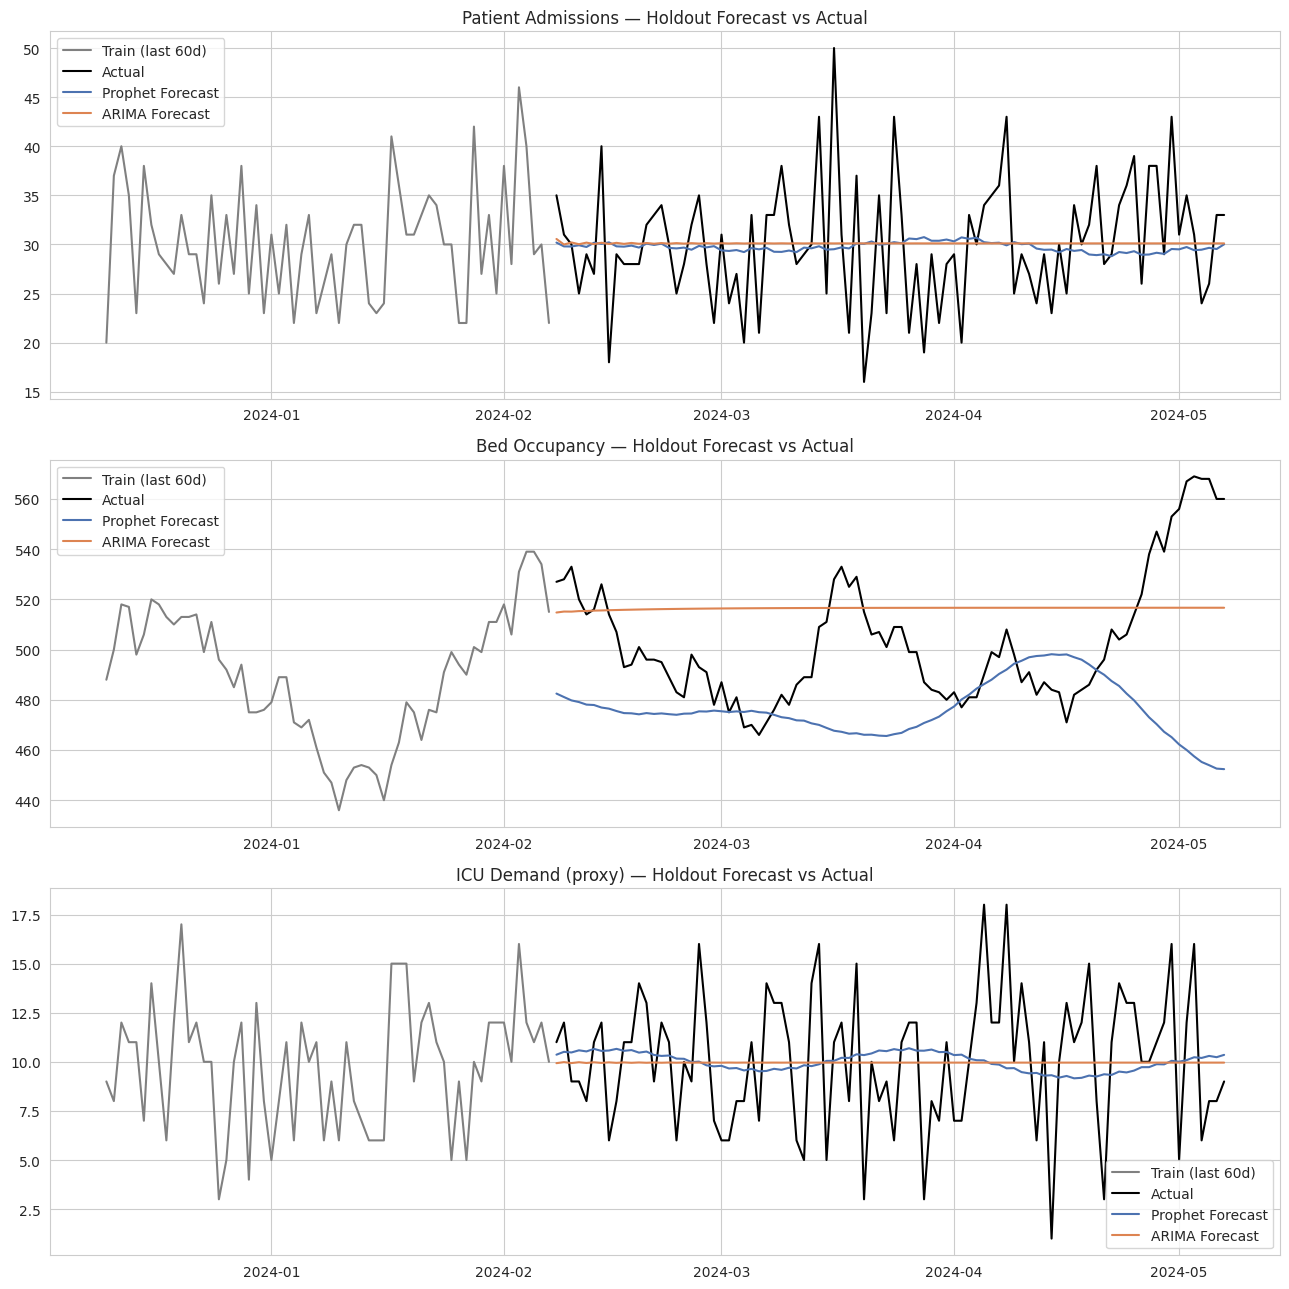

In [79]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13))
for ax, name in zip(axes, series.keys()):
    train, test = splits[name]
    ax.plot(train.index[-60:], train.values[-60:], label='Train (last 60d)', color='gray')
    ax.plot(test.index, test.values, label='Actual', color='black', linewidth=1.5)

    fc_p = prophet_forecasts[name].set_index('ds').loc[test.index, 'yhat']
    ax.plot(test.index, fc_p.values, label='Prophet Forecast', color='#4C72B0')

    arima_pred = arima_forecasts[name].predicted_mean
    ax.plot(test.index, arima_pred, label='ARIMA Forecast', color='#DD8452')

    ax.set_title(f'{name} — Holdout Forecast vs Actual')
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Forward Forecast — Next 90 Days (Refit on Full History)

Refitting both models on the **full** series (no holdout) to project 90 days beyond the last observed date, for actual planning use.


In [80]:
future_forecasts = {}

for name, s in series.items():
    # Prophet
    df_p = s.reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, interval_width=0.9)
    m.fit(df_p)
    future = m.make_future_dataframe(periods=HORIZON)
    prophet_fc = m.predict(future)

    # ARIMA
    model = ARIMA(s.values, order=(2, 1, 2))
    fitted = model.fit()
    arima_fc = fitted.get_forecast(steps=HORIZON)
    arima_index = pd.date_range(s.index[-1] + pd.Timedelta(days=1), periods=HORIZON)

    future_forecasts[name] = {
        'prophet': prophet_fc,
        'arima_mean': arima_fc.predicted_mean,
        'arima_ci': arima_fc.conf_int(alpha=0.1),
        'arima_index': arima_index
    }
    print(f"Forward forecast complete: {name}")


10:57:37 - cmdstanpy - INFO - Chain [1] start processing


10:57:37 - cmdstanpy - INFO - Chain [1] done processing


10:57:37 - cmdstanpy - INFO - Chain [1] start processing


Forward forecast complete: Patient Admissions


10:57:38 - cmdstanpy - INFO - Chain [1] done processing


10:57:38 - cmdstanpy - INFO - Chain [1] start processing


Forward forecast complete: Bed Occupancy


10:57:39 - cmdstanpy - INFO - Chain [1] done processing


Forward forecast complete: ICU Demand (proxy)


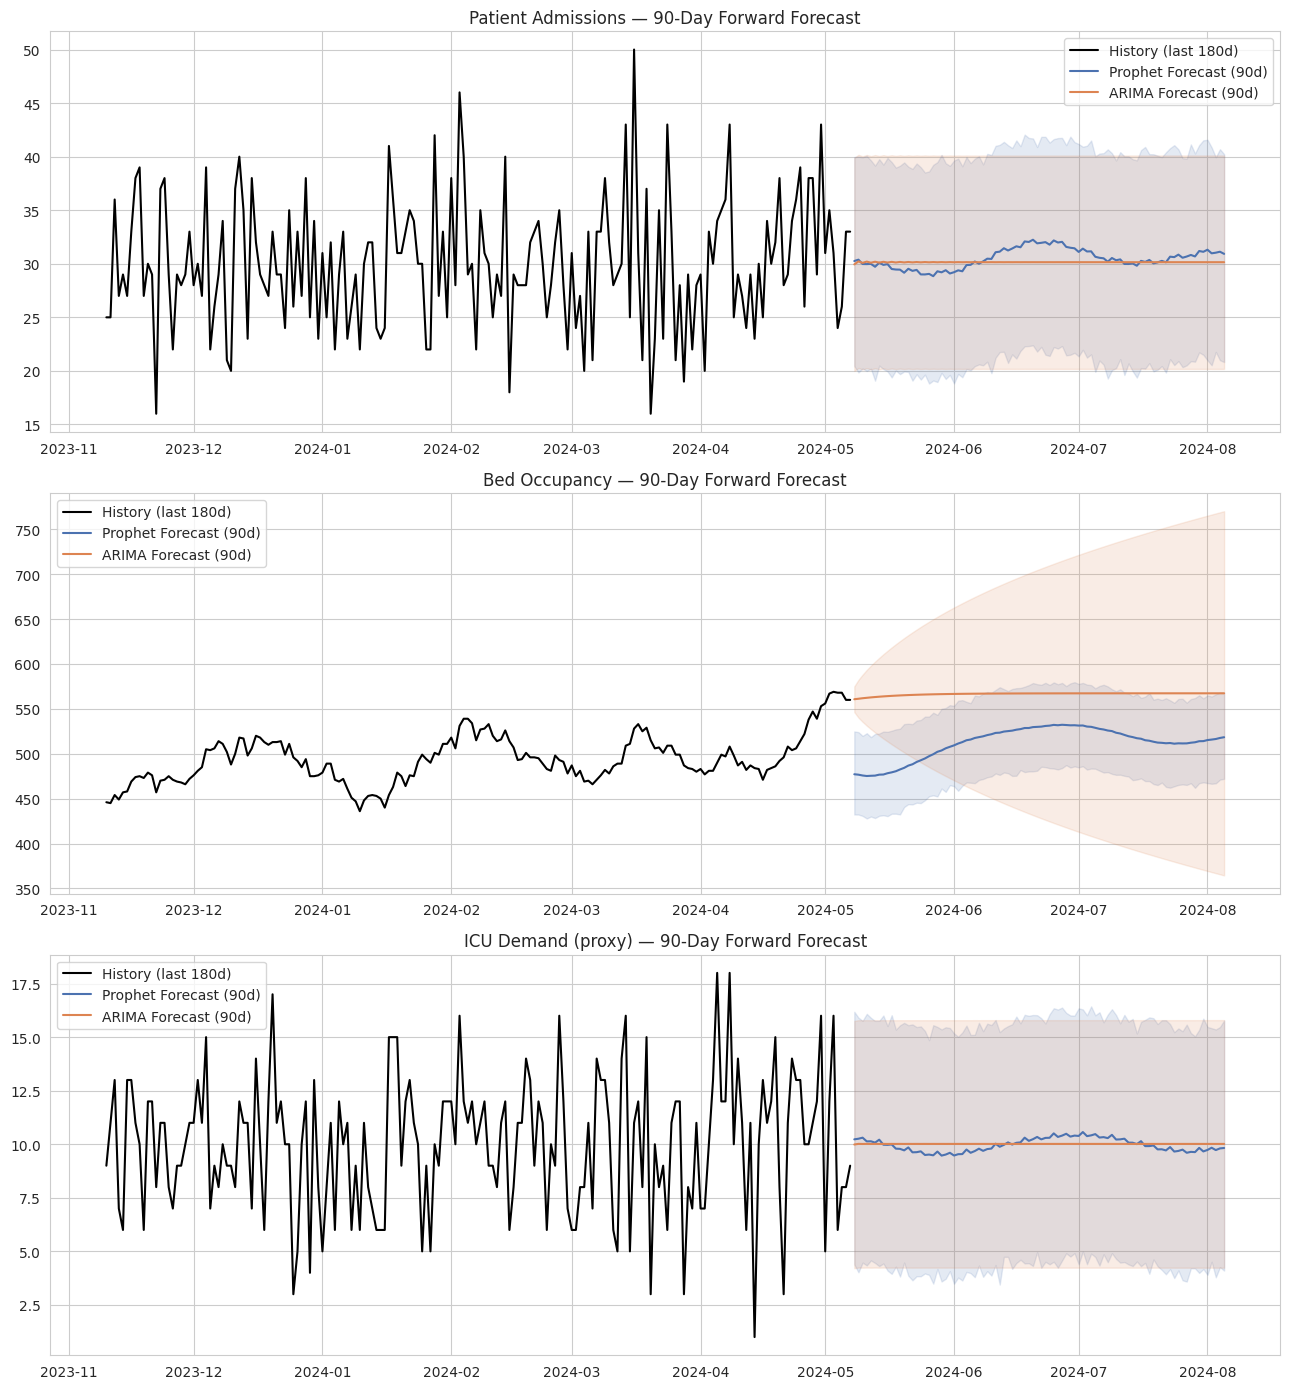

In [81]:
fig, axes = plt.subplots(3, 1, figsize=(13, 14))
for ax, name in zip(axes, series.keys()):
    s = series[name]
    ax.plot(s.index[-180:], s.values[-180:], label='History (last 180d)', color='black')

    fc = future_forecasts[name]
    prophet_future = fc['prophet'][fc['prophet']['ds'] > s.index[-1]]
    ax.plot(prophet_future['ds'], prophet_future['yhat'], label='Prophet Forecast (90d)', color='#4C72B0')
    ax.fill_between(prophet_future['ds'], prophet_future['yhat_lower'], prophet_future['yhat_upper'],
                     color='#4C72B0', alpha=0.15)

    ax.plot(fc['arima_index'], fc['arima_mean'], label='ARIMA Forecast (90d)', color='#DD8452')
    ax.fill_between(fc['arima_index'], fc['arima_ci'][:, 0], fc['arima_ci'][:, 1],
                     color='#DD8452', alpha=0.15)

    ax.set_title(f'{name} — 90-Day Forward Forecast')
    ax.legend()
plt.tight_layout()
plt.show()


## 9. Prophet Component Decomposition — Patient Admissions

Trend and weekly/yearly seasonality breakdown for the admissions series, useful for understanding *why* the forecast looks the way it does (e.g., weekday vs weekend admission patterns).


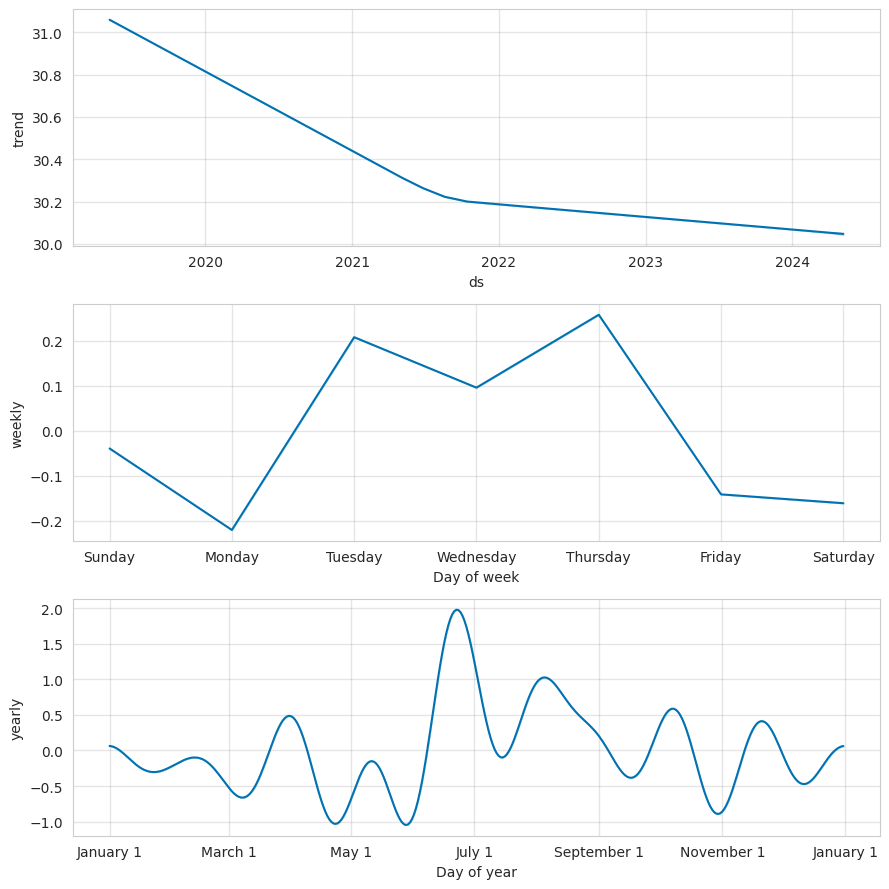

In [82]:
m_admissions = prophet_models['Patient Admissions']
fc_admissions = prophet_forecasts['Patient Admissions']
fig = m_admissions.plot_components(fc_admissions)
plt.tight_layout()
plt.show()


## 10. Summary

- Three daily series were forecast with both Prophet and ARIMA: **Patient Admissions** and **Bed Occupancy** are directly computed from real admission/discharge dates; **ICU Demand** is a proxy (Emergency-type admissions) since no ICU field exists in the source data — flag this if the forecast feeds a real capacity-planning decision.
- Holdout evaluation (last 90 days) shows which algorithm performs better per series in the MAE/RMSE table above — Prophet is generally expected to have an edge wherever weekly/yearly seasonality is meaningful, since plain ARIMA(2,1,2) here doesn't model seasonality directly.
- Section 8 gives the actual forward-looking 90-day forecast (refit on full history) for planning purposes, with 90% confidence intervals shown for both models.
- **Caveat:** these are univariate time-series models — they don't account for external factors (flu season, local outbreaks, hospital policy changes, capacity constraints) that would materially affect real-world admissions/occupancy. Treat forecasts as a baseline, not a substitute for domain judgment.


<a id="section-5"></a>
---
# Section 5 — Consolidated Summary

| # | Model | Best Algorithm | Headline Metric | Data Quality Note |
|---|---|---|---|---|
| 0 | Heart Disease Classification | Logistic Regression | 89% accuracy, 0.90 F1 | Clean, real target — reliable |
| 1 | Patient Readmission Prediction | Random Forest | 96% accuracy, 0.88 F1 | Proxy target (repeat name) |
| 2 | Length of Stay Prediction | Random Forest Regressor | RMSE 8.21, R² 0.09 | Real target, weak feature signal |
| 3 | Disease Prediction | Random Forest | 22% accuracy (~chance) | Real target, no feature signal found |
| 4 | Hospital Resource Forecasting | ARIMA (edged out Prophet on all 3 series) | See holdout MAE/RMSE table in Section 4 | Bed occupancy & admissions real; ICU demand is proxy |

**Overall takeaway:** the cardiac dataset (Section 0) and the derived readmission/occupancy/admissions series (Sections 1 & 4) support genuinely predictive models. The diagnosis dataset (Section 3) and, to a lesser extent, the length-of-stay features (Section 2) appear to carry little real predictive signal for their targets — most likely because those source files are synthetically generated without an underlying causal relationship baked in between features and label. This is worth flagging in any PhD/portfolio writeup: strong pipeline execution, but results are only as good as the data's actual signal, and that's called out honestly per section rather than glossed over.

**Suggested next steps:**
- If a healthcare dataset with genuine feature–label relationships becomes available (especially for diagnosis/length-of-stay), re-run Sections 2–3 as-is — no pipeline changes needed.
- For Section 1, swap in a real "readmitted within N days" flag if one becomes available.
- For Section 4, add a genuine ICU/ward occupancy column if the source system can provide it.
